<a href="https://colab.research.google.com/github/GabriellaPompeu/Learning-Pytorch/blob/main/IntroToNeuralNetwork.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [23]:
# Create a model class that inherits nn.Module
class Model(nn.Module):
  # Input layer (4 features of the flower) -->
  # Hidden Layer1 (number of neurons) -->
  # Hidden Layer2 (number of neurons) -->
  # output (3 classes of flowers)

  def __init__(self, in_features=4, h1=8, h2=9, out_features=3):
    super().__init__()
    self.fc1 = nn.Linear(in_features, h1)
    self.fc2 = nn.Linear(h1, h2)
    self.out = nn.Linear(h2, out_features)

  def forward(self, x):
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.out(x)

    return x

In [24]:
# Pick a manual seed for randomization. Obs.: I like the number 37
torch.manual_seed(37)
# Create an instance of model
model = Model()

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [26]:
url = 'https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/0e7a9b0a5d22642a06d3d5b9bcbad9890c8ee534/iris.csv'
my_df = pd.read_csv(url)

In [27]:
my_df.tail()

,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


In [28]:
# Change the names of species to numbers
my_df['species'] = my_df['species'].replace('setosa', 0.0)
my_df['species'] = my_df['species'].replace('versicolor', 1.0)
my_df['species'] = my_df['species'].replace('virginica', 2.0)

my_df

/tmp/ipykernel_2088/1221530390.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  my_df['species'] = my_df['species'].replace('virginica', 2.0)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0


In [29]:
# Train test split | Set X, Y
X = my_df.drop('species', axis=1)
y = my_df['species']

In [30]:
if isinstance(X, pd.DataFrame) or isinstance(X, pd.Series): # Check type before converting
    X = X.values # Convert to numpy arrays

if isinstance(y, pd.DataFrame) or isinstance(y, pd.Series): # Check type before converting
    y = y.values # Convert to numpy arrays

In [31]:
from sklearn.model_selection import train_test_split

In [32]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=41)

In [33]:
# Convert X features to floar tensors and convert y labels to tensors long
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [34]:
# Set the criterion of model measure the error
criterion = nn.CrossEntropyLoss()
# Choose Adam Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [35]:
# Train our model
# Epoch = 1 run through all the training data in our network

epochs = 100
losses = []

for i in range(epochs):
  y_pred = model.forward(X_train) # Get predicted results
  loss = criterion(y_pred, y_train)
  losses.append(loss.detach().numpy())
  if i % 10 == 0: print(f'Epoch {i} and loss {loss}')
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

Epoch 0 and loss 1.1260454654693604
Epoch 10 and loss 0.8988741040229797
Epoch 20 and loss 0.6125052571296692
Epoch 30 and loss 0.3780321478843689
Epoch 40 and loss 0.23913885653018951
Epoch 50 and loss 0.13712693750858307
Epoch 60 and loss 0.08320225030183792
Epoch 70 and loss 0.05890814587473869
Epoch 80 and loss 0.04682008922100067
Epoch 90 and loss 0.039843037724494934


Text(0.5, 0, 'Epoch')

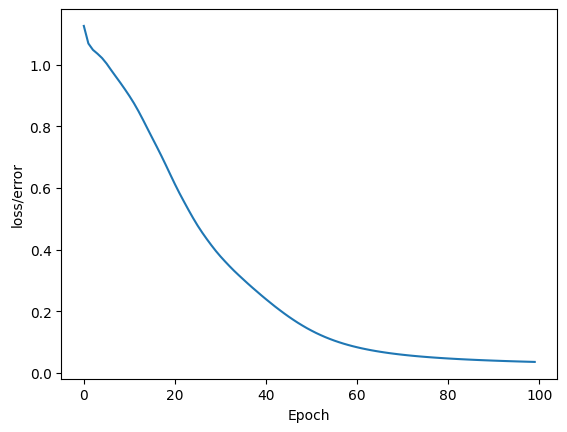

In [36]:
# Graph all this
plt.plot(range(epochs), losses)
plt.ylabel("loss/error")
plt.xlabel("Epoch")